# Iterative IsoDiffusion Results Viewer
This notebook provides interactive widgets to visualize the 3D `.npy` volumes, inspect the reconstructed volumes over multiple rounds, and compute/plot metrics.

In [1]:
import sys, importlib
from pathlib import Path
# ── Path setup ────────────────────────────────────────────────────────────
project_root = Path('/myhome/sdate')
sys.path.insert(0, str(project_root))


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import ipywidgets as widgets
from ipywidgets import interact
from skimage.metrics import peak_signal_noise_ratio, structural_similarity, mean_squared_error

import torch


def fft_2D(x, s=None, ortho:bool=False, dim=[-1, -2]):
    # if len(x.shape) == 2:
    #     raise Exception("Expects at least dimensions (b, w, h)")
    if ortho:
        fft_image = torch.fft.fftn(x, s=s, norm='ortho', dim=dim)
    else:
        fft_image = torch.fft.fftn(x, s=s, dim=dim)
    return torch.fft.fftshift(fft_image, dim=dim)


def ifft_2D(x, ortho:bool=False, dim=[-1, -2]):
    # if len(x.shape) == 2:
    #     raise Exception("Expects at least dimensions (b, w, h)")
    f_space = torch.fft.ifftshift(x, dim=dim)
    # Perform inverse 2D Fourier Transform
    if ortho:
        return torch.fft.ifftn(f_space, norm='ortho', dim=dim)
    else:
        return torch.fft.ifftn(f_space, dim=dim)


import lovely_tensors as lt
lt.monkey_patch()

## 1. Single Volume Visualization
Point to any `.npy` volume to slice through it.

In [3]:
def inspect_single_volume(volume_path, axis=0, volume_path_comparison=None, cmap='gray'):
    path = Path(volume_path)
    if not path.exists():
        print(f"File not found: {path}")
        return
    vol = np.load(path)
    print(f"Vol 1 — shape: {vol.shape}, dtype: {vol.dtype}, range: [{vol.min():.4f}, {vol.max():.4f}]")

    axis_labels = ['Z', 'Y', 'X']
    label = axis_labels[axis] if axis < len(axis_labels) else str(axis)
    vmin, vmax = np.percentile(vol, [1, 99])

    if volume_path_comparison is not None:
        path2 = Path(volume_path_comparison)
        if not path2.exists():
            print(f"Comparison file not found: {path2}")
            return
        vol2 = np.load(path2)
        print(f"Vol 2 — shape: {vol2.shape}, dtype: {vol2.dtype}, range: [{vol2.min():.4f}, {vol2.max():.4f}]")
        if vol.shape != vol2.shape:
            print(f"Shape mismatch: {vol.shape} vs {vol2.shape}")
            return
        diff = vol - vol2
        abs_max = np.percentile(np.abs(diff), 99)

        def show_slice(idx):
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            s1 = np.take(vol, idx, axis=axis)
            s2 = np.take(vol2, idx, axis=axis)
            sd = np.take(diff, idx, axis=axis)

            axes[0].imshow(s1, cmap=cmap, vmin=vmin, vmax=vmax)
            axes[0].set_title(f"Vol 1 — {label}-slice {idx}")
            axes[0].axis('off')

            axes[1].imshow(s2, cmap=cmap, vmin=vmin, vmax=vmax)
            axes[1].set_title(f"Vol 2 — {label}-slice {idx}")
            axes[1].axis('off')

            im = axes[2].imshow(sd, cmap='RdBu_r', vmin=-abs_max, vmax=abs_max)
            axes[2].set_title(f"Difference (Vol1 - Vol2) — {label}-slice {idx}")
            axes[2].axis('off')
            plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

            plt.tight_layout()
            plt.show()
    else:
        def show_slice(idx):
            plt.figure(figsize=(8, 8))
            plt.imshow(np.take(vol, idx, axis=axis), cmap=cmap, vmin=vmin, vmax=vmax)
            plt.title(f"{label}-slice: {idx}")
            plt.axis('off')
            plt.show()

    max_idx = vol.shape[axis] - 1
    interact(show_slice, idx=widgets.IntSlider(min=0, max=max_idx, step=1, value=max_idx//2))
    return vol

In [4]:
# file_idx = 125
# vol1 = inspect_single_volume(
#     # f'/myhome/data/sdate/shared/smartt/sici_volumes/ampsf_128dirs/ampsf_128dirs_channel_{file_idx}.npy', 
#     f'/myhome/data/sdate/shared/smartt/sici_volumes/amps2_128dirs/amps2_128dirs_channel_{file_idx}.npy',
#     2,
#     cmap='viridis'
# ) 

# vol2 = inspect_single_volume(
#     f'/myhome/data/sdate/shared/smartt/sici_volumes/ampsf_128dirs/ampsf_128dirs_channel_{file_idx}.npy', 
#     # f'/myhome/data/sdate/shared/smartt/sici_volumes/amps1_128dirs/amps1_128dirs_channel_{file_idx}.npy',
#     2,
#     cmap='viridis'
# ) 
# vol1_t = torch.from_numpy(vol1)
# vol2_t = torch.from_numpy(vol2)

# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# axes[0].imshow(vol1_t.sum(dim=1))
# axes[1].imshow(vol2_t.sum(dim=1))

In [5]:
# vol = inspect_single_volume('/myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/la_fourier_1.npy', axis=0)

In [6]:
# Example usage:
# inspect_single_volume('/myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/la_fourier_1.npy', axis=1)
# vol = inspect_single_volume(
#     f'/myhome/data/sdate/shared/smartt/sici_volumes/amps1_128dirs/amps1_128dirs_channel_{file_idx}.npy',
#     1,
#     cmap='viridis'
# ) 

vol = inspect_single_volume('/myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/gt_fbp_1.npy', axis=0)

Vol 1 — shape: (540, 640, 640), dtype: float32, range: [-0.0362, 0.0499]


interactive(children=(IntSlider(value=269, description='idx', max=539), Output()), _dom_classes=('widget-inter…

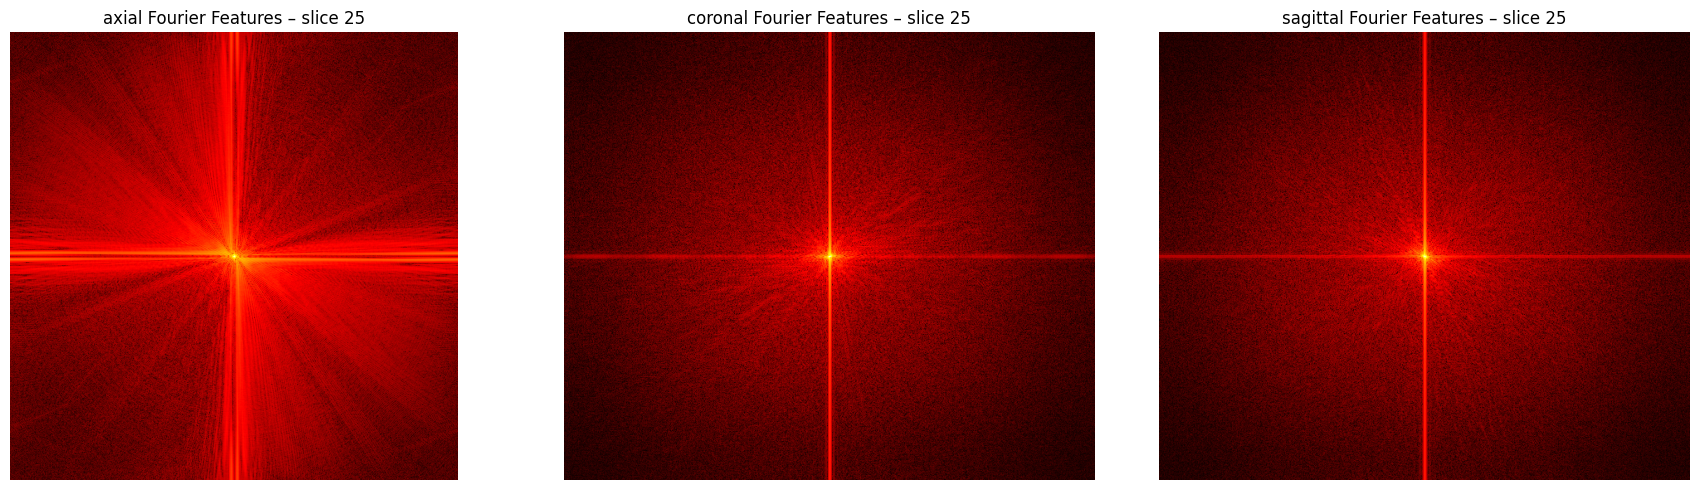

In [7]:
import torch
vol_t = torch.from_numpy(vol)

IDX_SLICE = 25
fft_inputs ={
    'axial': vol_t.sum(dim=0),
    'coronal': vol_t.sum(dim=1),
    'sagittal': vol_t.sum(dim=2),
}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, image) in zip(axes, fft_inputs.items()):
    fft_recon = fft_2D(image)
    magnitude = torch.log1p(torch.abs(fft_recon))
    ax.imshow(magnitude.cpu().detach(), cmap='hot')
    ax.set_title(f'{title} Fourier Features – slice {IDX_SLICE}')
    ax.axis('off')

plt.tight_layout()
plt.show()



## 2. Iterative Reconstructions Visualization
Visualize how the reconstruction improves over the iterative rounds.

In [ ]:
def inspect_iterative_reconstructions(output_dir, condition_path=None, ground_truth_path=None):
    out_path = Path(output_dir)
    recons = sorted(list(out_path.glob("*.npy")))
    if not recons:
        print(f"No reconstructions found in {output_dir}")
        return
        
    print(f"Found {len(recons)} rounds of reconstruction.")
    volumes = [np.load(p) for p in recons]
    
    cond_vol = np.load(condition_path) if condition_path else None
    gt_vol = np.load(ground_truth_path) if ground_truth_path else None
    
    # Use the first round's percentile for consistent display, or the condition if available
    ref_vol = gt_vol if gt_vol is not None else cond_vol
    vmin, vmax = np.percentile(ref_vol, [2, 98])

    def fft_magnitude(arr_2d):
        t = torch.from_numpy(arr_2d.astype(np.float32))
        return torch.log1p(torch.abs(fft_2D(t))).numpy()
    
    def show_round_slice(round_idx, z):
        num_plots = 1
        if cond_vol is not None: num_plots += 1
        if gt_vol is not None: num_plots += 2  # GT and Error map
            
        fig, axes = plt.subplots(2, num_plots, figsize=(6*num_plots, 12))
        if num_plots == 1:
            axes = axes.reshape(2, 1)
            
        col = 0
        if cond_vol is not None:
            axes[0, col].imshow(cond_vol[z], cmap='gray', vmin=vmin, vmax=vmax)
            axes[0, col].set_title('Starting Condition')
            axes[0, col].axis('off')
            axes[1, col].imshow(fft_magnitude(cond_vol[z]), cmap='hot')
            axes[1, col].set_title('Starting Condition – Fourier')
            axes[1, col].axis('off')
            col += 1
            
        axes[0, col].imshow(volumes[round_idx][z], cmap='gray', vmin=vmin, vmax=vmax)
        axes[0, col].set_title(f'Reconstruction Round {round_idx}')
        axes[0, col].axis('off')
        axes[1, col].imshow(fft_magnitude(volumes[round_idx][z]), cmap='hot')
        axes[1, col].set_title(f'Reconstruction Round {round_idx} – Fourier')
        axes[1, col].axis('off')
        col += 1
        
        if gt_vol is not None:
            axes[0, col].imshow(gt_vol[z], cmap='gray', vmin=vmin, vmax=vmax)
            axes[0, col].set_title('Ground Truth')
            axes[0, col].axis('off')
            axes[1, col].imshow(fft_magnitude(gt_vol[z]), cmap='hot')
            axes[1, col].set_title('Ground Truth – Fourier')
            axes[1, col].axis('off')
            col += 1
            
            err = np.abs(volumes[round_idx][z] - gt_vol[z])
            axes[0, col].imshow(err, cmap='magma')
            axes[0, col].set_title('|Error|')
            axes[0, col].axis('off')
            axes[1, col].imshow(fft_magnitude(err), cmap='hot')
            axes[1, col].set_title('|Error| – Fourier')
            axes[1, col].axis('off')
            
        plt.tight_layout()
        plt.show()
        
    max_z = volumes[0].shape[0] - 1
    interact(show_round_slice, 
             round_idx=widgets.IntSlider(min=0, max=len(volumes)-1, step=1, value=len(volumes)-1),
             z=widgets.IntSlider(min=0, max=max_z, step=1, value=max_z//2))

In [11]:
# Example usage:
# inspect_iterative_reconstructions(
#     output_dir='/myhome/sdate/outputs/iterative_test',
#     condition_path='/myhome/sdate/outputs/iterative_test/cropped_condition_96.npy',
#     ground_truth_path='/myhome/sdate/outputs/iterative_test/cropped_gt_96.npy'
# )
# output_dir='/mydata/sdate/shared/compression_paper/file_1_extracted/reconstruction/isonet_la_40_percent'
# ground_truth_path = '/myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/gt_fbp_1.npy'
# condition_path='/myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/la_fbp_1.npy'

output_dir='/myhome/data/smartt/shared/isonet_results/frogbone/round_00'
ground_truth_path = None
condition_path='/myhome/data/smartt/shared/isonet_results/frogbone/round_00/vol_0001.npy'


inspect_iterative_reconstructions(
    output_dir=output_dir,
    condition_path=condition_path,
    ground_truth_path=ground_truth_path
)


Found 30 rounds of reconstruction.


interactive(children=(IntSlider(value=29, description='round_idx', max=29), IntSlider(value=31, description='z…

## 3. Metrics Over Rounds
Evaluate and plot PSNR, MSE, and SSIM for all available rounds.

In [10]:
def compute_and_plot_metrics(output_dir, ground_truth_path, condition_path=None):
    out_path = Path(output_dir)
    recons = sorted(list(out_path.glob("*reconstruction_round_*.npy")))
    if not recons:
        print(f"No reconstructions found in {output_dir}")
        return
        
    gt_vol = np.load(ground_truth_path)

    # Compute baseline metrics (condition vs ground truth)
    baseline_psnr = baseline_ssim = None
    if condition_path is not None:
        cond_vol = np.load(condition_path)
        b_psnrs, b_ssims = [], []
        for z in range(cond_vol.shape[0]):
            slice_c = cond_vol[z]
            slice_g = gt_vol[z]
            data_range = slice_g.max() - slice_g.min()
            if data_range == 0: data_range = 1.0
            b_psnrs.append(peak_signal_noise_ratio(slice_g, slice_c, data_range=data_range))
            b_ssims.append(structural_similarity(slice_g, slice_c, data_range=data_range))
        baseline_psnr = np.mean(b_psnrs)
        baseline_ssim = np.mean(b_ssims)
        print(f"Baseline (condition vs GT) — PSNR: {baseline_psnr:.4f} dB  |  SSIM: {baseline_ssim:.4f}")

    rounds = []
    avg_psnrs = []
    avg_mses = []
    avg_ssims = []
    
    print("Computing metrics... this may take a moment.")
    for p in recons:
        rnd = int(p.stem.split('_')[-1])
        recon = np.load(p)
        
        psnrs, mses, ssims = [], [], []
        for z in range(recon.shape[0]):
            slice_r = recon[z]
            slice_g = gt_vol[z]
            data_range = slice_g.max() - slice_g.min()
            if data_range == 0: data_range = 1.0
                
            psnrs.append(peak_signal_noise_ratio(slice_g, slice_r, data_range=data_range))
            mses.append(mean_squared_error(slice_g, slice_r))
            ssims.append(structural_similarity(slice_g, slice_r, data_range=data_range))
            
        rounds.append(rnd)
        avg_psnrs.append(np.mean(psnrs))
        avg_mses.append(np.mean(mses))
        avg_ssims.append(np.mean(ssims))
        
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(rounds, avg_psnrs, marker='o', color='blue', label='Reconstruction')
    if baseline_psnr is not None:
        axes[0].axhline(baseline_psnr, color='orange', linestyle='--', linewidth=1.5,
                        label=f'Baseline (condition) {baseline_psnr:.2f} dB')
    axes[0].set_title('PSNR over Rounds')
    axes[0].set_xlabel('Round')
    axes[0].set_ylabel('PSNR (dB)')
    axes[0].grid(True)
    axes[0].set_xticks(rounds)
    axes[0].legend()
    
    axes[1].plot(rounds, avg_mses, marker='o', color='red')
    axes[1].set_title('MSE over Rounds')
    axes[1].set_xlabel('Round')
    axes[1].set_ylabel('MSE')
    axes[1].grid(True)
    axes[1].set_xticks(rounds)
    
    axes[2].plot(rounds, avg_ssims, marker='o', color='green', label='Reconstruction')
    if baseline_ssim is not None:
        axes[2].axhline(baseline_ssim, color='orange', linestyle='--', linewidth=1.5,
                        label=f'Baseline (condition) {baseline_ssim:.4f}')
    axes[2].set_title('SSIM over Rounds')
    axes[2].set_xlabel('Round')
    axes[2].set_ylabel('SSIM')
    axes[2].grid(True)
    axes[2].set_xticks(rounds)
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    return rounds, avg_psnrs, avg_mses, avg_ssims

In [11]:
# Example usage:
compute_and_plot_metrics(
    output_dir=output_dir,
    ground_truth_path=ground_truth_path,
    condition_path=condition_path,
)

TypeError: expected str, bytes or os.PathLike object, not NoneType

## 3.5. Save Reconstructions as HEVC Video

Export the iterative reconstruction volumes to HEVC 10-bit `.mov` files saved alongside the `.npy` files in `output_dir`. Each round is encoded as a video with one frame per slice; an optional `time_evolution.mov` captures the middle slice across all rounds.

In [ ]:
import shutil
import subprocess

if shutil.which("ffmpeg") is None:
    print("ffmpeg not found — installing...")
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(["apt-get", "install", "-y", "ffmpeg"], check=True)
    print(f"ffmpeg installed: {shutil.which('ffmpeg')}")
else:
    print(f"ffmpeg found: {shutil.which('ffmpeg')}")

ffmpeg found: /usr/bin/ffmpeg


In [ ]:
import torch
from tqdm import tqdm
from sdate.stream_hvec.stream_gray10 import HevcGray10Streamer, EncoderParams

vmin, vmax = np.percentile(vol, [2, 98])

def save_reconstructions_to_video(
    output_dir,
    axis: int = 0,
    fps: int = 24,
    crf: int = 14,
    save_per_round: bool = True,
    save_time_evolution: bool = True,
):
    """Save iterative reconstruction .npy volumes as HEVC 10-bit .mov files.

    Videos are written to output_dir alongside the .npy files:
      - Per-round: reconstruction_round_N.npy → reconstruction_round_N.mov
      - Time evolution: middle slice across all rounds → time_evolution.mov

    Args:
        output_dir: directory containing *reconstruction_round_*.npy files.
        axis: volume axis to iterate over as frames (0=axial, 1=coronal, 2=sagittal).
        fps: frames per second for the output video.
        crf: libx265 CRF quality value (lower = better quality, larger file).
        save_per_round: encode one video per reconstruction round.
        save_time_evolution: encode a video of the middle slice across all rounds.
    """
    out_path = Path(output_dir)
    recon_files = sorted(out_path.glob("*reconstruction_round_*.npy"))
    if not recon_files:
        print(f"No reconstruction files found in {out_path}")
        return

    params = EncoderParams(fps=fps, crf_sw=crf, force_software=True)

    if save_per_round:
        print(f"Encoding {len(recon_files)} per-round video(s)...")
        for recon_path in recon_files:
            vol = np.load(recon_path).astype(np.float32)
            v_min, v_max = float(vol.min()), float(vol.max())
            vol_norm = (vol - v_min) / (v_max - v_min) if v_max > v_min else np.zeros_like(vol)

            out_video = out_path / recon_path.with_suffix(".mov").name
            streamer = HevcGray10Streamer(base_path=out_path, params=params)
            with streamer.start_segment(outfile=out_video.name):
                for i in tqdm(range(vol_norm.shape[axis])):
                    frame = torch.from_numpy(np.take(vol_norm, i, axis=axis).copy())
                    streamer.append_frame(frame)
            print(f"  Saved: {out_video.name}")

    if save_time_evolution and len(recon_files) > 1:
        print("Encoding time-evolution video (middle slice across all rounds)...")
        vols = [np.load(p).astype(np.float32) for p in recon_files]
        g_min = vmin
        g_max = vmax
        mid_idx = vols[0].shape[axis] // 2

        out_video = out_path / "time_evolution.mov"
        streamer = HevcGray10Streamer(base_path=out_path, params=params)
        with streamer.start_segment(outfile=out_video.name):
            for vol in vols:
                vol_norm = (vol - g_min) / (g_max - g_min) if g_max > g_min else np.zeros_like(vol)
                frame = torch.from_numpy(np.take(vol_norm, mid_idx, axis=axis).copy())
                streamer.append_frame(frame)
        print(f"  Saved: {out_video.name}")

    print("Done.")

In [ ]:
# Save reconstructions as HEVC video — videos are written to output_dir alongside the .npy files
save_reconstructions_to_video(
    output_dir=output_dir,
    axis=0,    # slice axis: 0=axial, 1=coronal, 2=sagittal
    fps=10,
    crf=14,    # libx265 CRF: lower = better quality, larger file
)

Encoding 1 per-round video(s)...


## 4. Dataset-wide PSNR Survey
Iterate over all 128 channel indices, compute per-volume PSNR between the missing-wedge reconstruction (`amps2`) and the ground truth (`ampsf`), and identify the worst cases.

In [ ]:
from tqdm.auto import tqdm

RECON_DIR  = Path('/myhome/data/sdate/shared/smartt/sici_volumes/amps2_128dirs')
GT_DIR     = Path('/myhome/data/sdate/shared/smartt/sici_volumes/ampsf_128dirs')
N_CHANNELS = 128

psnr_per_idx = {}
missing = []

for idx in tqdm(range(N_CHANNELS), desc="Computing PSNR"):
    recon_path = RECON_DIR / f'amps2_128dirs_channel_{idx}.npy'
    gt_path    = GT_DIR    / f'ampsf_128dirs_channel_{idx}.npy'
    if not recon_path.exists() or not gt_path.exists():
        missing.append(idx)
        continue
    recon_proj = np.load(recon_path).astype(np.float32).sum(axis=1)
    gt_proj    = np.load(gt_path).astype(np.float32).sum(axis=1)
    min_val,  max_val = np.percentile(gt_proj, [2, 98])
    data_range = max_val - min_value
    gt_proj = gt_proj.clip(min_value, max_value)
    recon_proj = recon_proj.clip(min_value, max_value)

    if data_range == 0:
        data_range = 1.0
    psnr_per_idx[idx] = peak_signal_noise_ratio(gt_proj, recon_proj, data_range=data_range)

if missing:
    print(f"Missing files for indices: {missing}")

indices = sorted(psnr_per_idx)
psnr_values = [psnr_per_idx[i] for i in indices]

# --- Plot PSNR vs index ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(indices, psnr_values, marker='o', markersize=3, linewidth=1, color='steelblue')
ax.set_xlabel('Channel index')
ax.set_ylabel('PSNR (dB)')
ax.set_title('PSNR on sum(dim=1) projection: amps2 vs ground truth (all 128 channels)')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# --- Top 5 worst ---
worst5 = sorted(psnr_per_idx, key=lambda i: psnr_per_idx[i])[:5]
print("\nTop 5 worst reconstruction indices (lowest PSNR on projection):")
for rank, idx in enumerate(worst5, 1):
    print(f"  #{rank}  channel {idx:3d}  —  PSNR = {psnr_per_idx[idx]:.2f} dB")

Computing PSNR:   0%|          | 0/128 [00:00<?, ?it/s]

NameError: name 'min_value' is not defined

In [ ]:
# --- Projection visualizations for the 5 worst channels ---
for rank, idx in enumerate(worst5, 1):
    recon = np.load(RECON_DIR / f'amps2_128dirs_channel_{idx}.npy').astype(np.float32)
    gt    = np.load(GT_DIR    / f'ampsf_128dirs_channel_{idx}.npy').astype(np.float32)
    vol1_t = torch.from_numpy(recon)
    vol2_t = torch.from_numpy(gt)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(vol1_t.sum(dim=1), cmap='viridis')
    axes[0].set_title(f'Reconstruction  (channel {idx})')
    axes[0].axis('off')
    axes[1].imshow(vol2_t.sum(dim=1), cmap='viridis')
    axes[1].set_title(f'Ground truth  (channel {idx})')
    axes[1].axis('off')
    fig.suptitle(f'#{rank} worst — channel {idx}  |  PSNR = {psnr_per_idx[idx]:.2f} dB', fontsize=13)
    plt.tight_layout()
    plt.show()